# 🌸 Iris Flower Classification — CodeAlpha Data Science Internship (Task 1)

**Problem statement:** Given four measurements of an Iris flower (sepal length, sepal width, petal length, petal width), predict which of three species it belongs to: *setosa*, *versicolor* or *virginica*.

**Type of problem:** Supervised learning → **multi-class classification** (the answer is a category, not a number).

**How to run:** In Google Colab or Jupyter, run each cell from top to bottom (Shift + Enter). If you have `Iris.csv` from the CodeAlpha / Kaggle link, upload it next to this notebook. If not, the notebook automatically uses the identical copy of the dataset built into Scikit-learn — so it always runs.

## Step 1 — Import libraries
**What:** Loads the tools we need.
- `pandas` → tables (DataFrames), `numpy` → maths
- `matplotlib` / `seaborn` → charts
- `sklearn` (Scikit-learn) → datasets, models, evaluation
- `joblib` → saving the trained model to a file

**Expected output:** Library versions printed. If you see `ModuleNotFoundError`, run `!pip install -r requirements.txt` (or `!pip install seaborn scikit-learn`).

In [25]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42          # fixed seed → same results every time you run the notebook
os.makedirs("images", exist_ok=True)   # folder for saving charts (for GitHub/LinkedIn)
os.makedirs("models", exist_ok=True)   # folder for saving the trained model

print("pandas:", pd.__version__, "| scikit-learn:", sklearn.__version__, "| seaborn:", sns.__version__)

pandas: 2.2.3 | scikit-learn: 1.6.1 | seaborn: 0.13.2


## Step 2 — Load the dataset
**What:** Tries to read `Iris.csv` (Kaggle format: `Id, SepalLengthCm, …, Species`). If the file is missing, it falls back to `load_iris()` from Scikit-learn.

**Why the renaming?** The two sources use different column names and species labels (`Iris-setosa` vs `setosa`). We convert both to one clean format so the rest of the notebook works either way.

**Expected output:** A message saying which source was used, and the first 5 rows.

In [22]:
CSV_PATH = next((p for p in ["Iris.csv", os.path.join("data", "Iris.csv")] if os.path.exists(p)), "Iris.csv")

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    source = f"CSV file: {CSV_PATH}"
    df = df.rename(columns={
        "SepalLengthCm": "sepal_length", "SepalWidthCm": "sepal_width",
        "PetalLengthCm": "petal_length", "PetalWidthCm": "petal_width",
        "Species": "species",
    })
    df = df.drop(columns=["Id"], errors="ignore")          # Id is just a row number, not a feature
    df["species"] = df["species"].astype(str).str.replace("Iris-", "", regex=False).str.strip()
else:
    iris = load_iris(as_frame=True)
    df = iris.frame.copy()
    df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "target"]
    df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
    df = df.drop(columns=["target"])
    source = "scikit-learn built-in load_iris()"

FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
TARGET = "species"

missing_cols = [c for c in FEATURES + [TARGET] if c not in df.columns]
assert not missing_cols, f"These expected columns are missing: {missing_cols}. Check your CSV headers."

print("Data source used ->", source)
df.head()

Data source used -> scikit-learn built-in load_iris()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Step 3 — Understand the dataset
**What:** Shape (rows × columns), data types, and summary statistics.

**Expected output:** 150 rows × 5 columns; four numeric (`float64`) features in centimetres; one text column `species`; 50 flowers per species (a *balanced* dataset — each class is equally represented, so accuracy is a fair metric here).

In [23]:
print("Shape (rows, columns):", df.shape)
print("\nData types / non-null counts:")
df.info()
print("\nClass distribution:")
print(df[TARGET].value_counts())
df.describe().round(2)

Shape (rows, columns): (150, 5)

Data types / non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## Step 4 — Data cleaning: missing values & duplicates
**Missing values:** we count empty cells per column. Iris normally has none; if some appear (e.g. a damaged CSV), we drop those rows because the dataset is tiny and imputing measurements could mislead the model.

**Duplicates:** Iris contains a few identical rows. They could be real flowers with the same measurements, but if one copy lands in training and the other in testing, the test becomes slightly "too easy" (a mild form of **data leakage**). Removing them is the safer, more honest choice.

**Expected output:** 0 missing values; a small number of duplicate rows removed (usually 1 for the Scikit-learn version, 3 for the Kaggle CSV).

In [24]:
print("Missing values per column:\n", df.isnull().sum())
df = df.dropna(subset=FEATURES + [TARGET])

# make sure feature columns are numeric (protects against text in a corrupted CSV)
for col in FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=FEATURES)

n_dupes = df.duplicated().sum()
print(f"\nDuplicate rows found: {n_dupes}")
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after cleaning:", df.shape)
print(df[TARGET].value_counts())

Missing values per column:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate rows found: 1
Shape after cleaning: (149, 5)
species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64


## Step 5 — Exploratory Data Analysis (EDA)
EDA = looking at the data with charts **before** modelling, to understand patterns.

### 5a. Class balance
**Expected:** three bars of (almost) equal height.

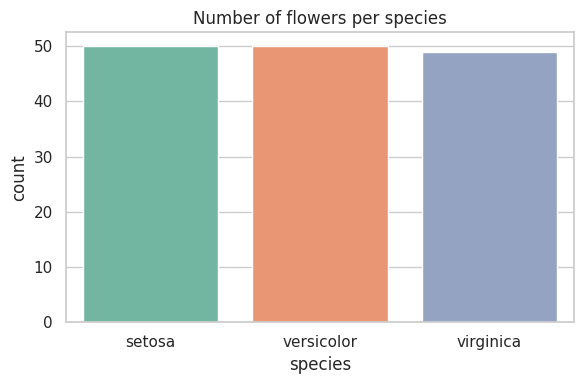

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET, hue=TARGET, palette="Set2", legend=False)
plt.title("Number of flowers per species")
plt.tight_layout()
plt.savefig("images/01_class_distribution.png", dpi=120)
plt.show()

### 5b. Pair plot — every feature against every other
**How to read it:** each dot is a flower, coloured by species. The diagonal shows the distribution of each feature.

**What to look for:** *setosa* usually forms a completely separate cluster in the petal plots, while *versicolor* and *virginica* overlap a little. That overlap is where the model will make its (few) mistakes.

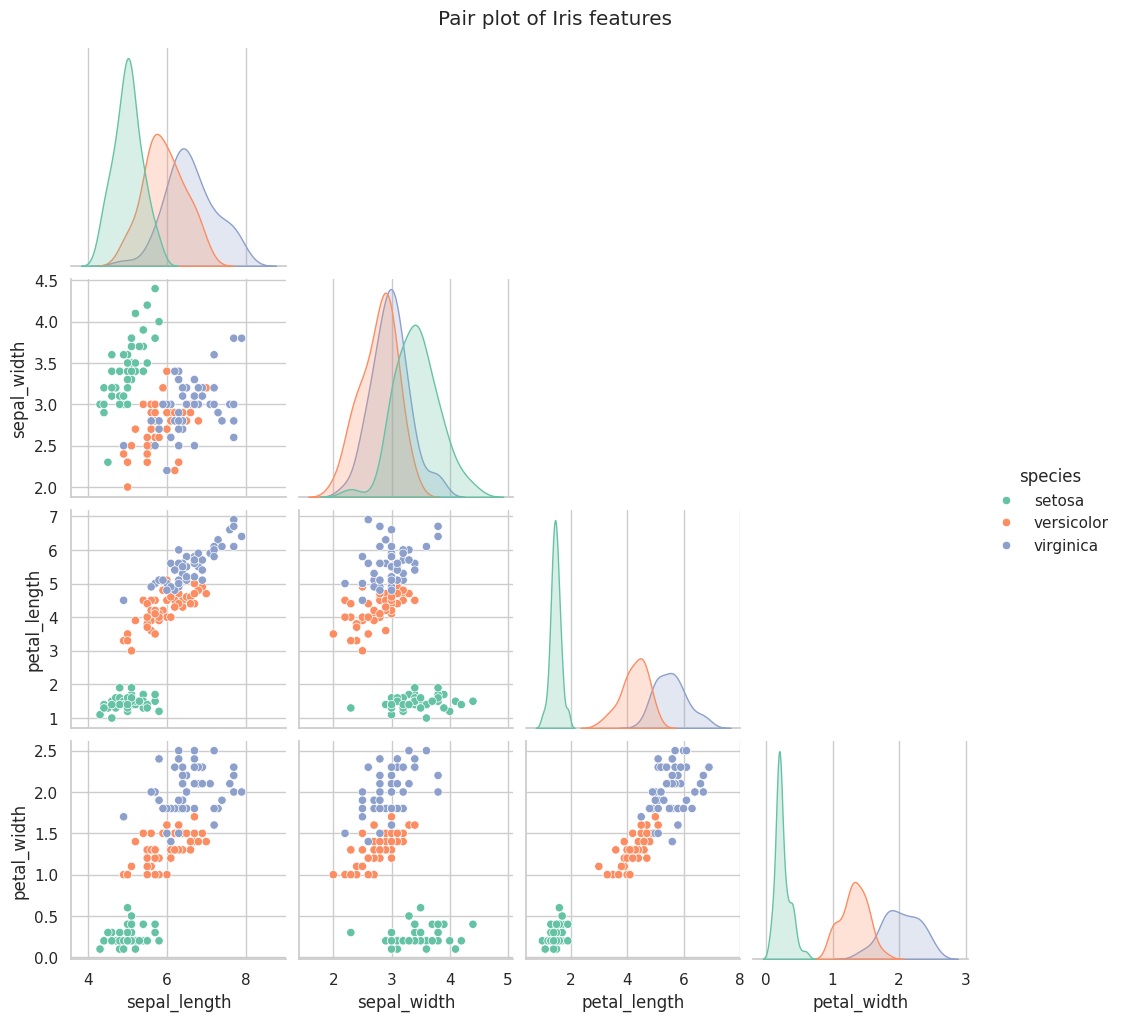

In [27]:
sns.pairplot(df, hue=TARGET, palette="Set2", corner=True, diag_kind="kde")
plt.suptitle("Pair plot of Iris features", y=1.02)
plt.savefig("images/02_pairplot.png", dpi=120, bbox_inches="tight")
plt.show()

### 5c. Box plots per feature
A box plot shows the median (middle line), the middle 50% of values (the box), and outliers (dots). If the boxes of different species don't overlap, that feature separates the species well.

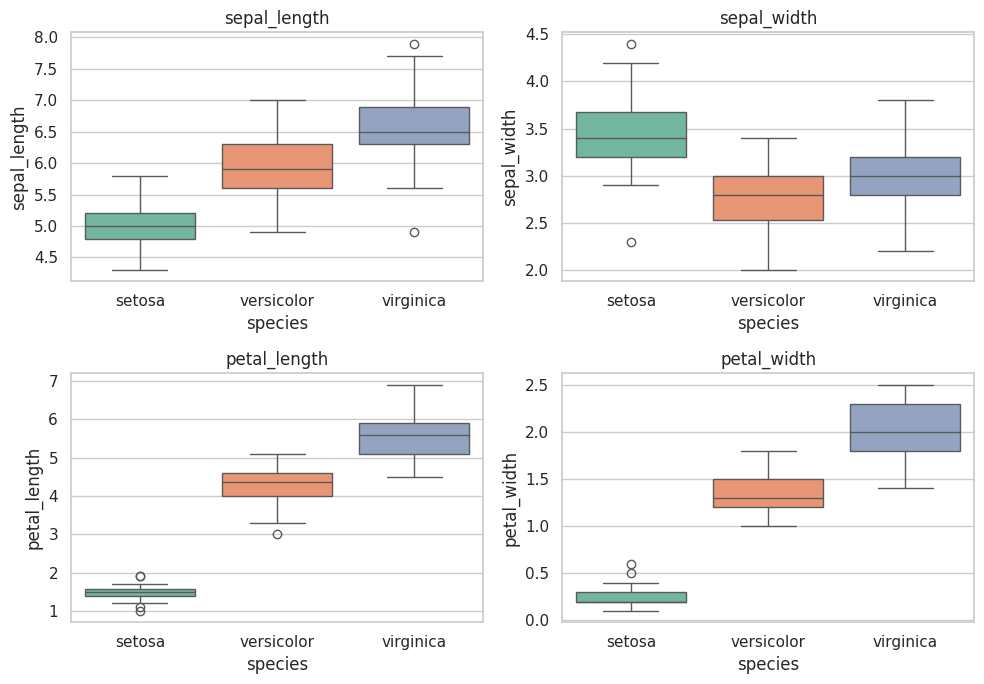

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=df, x=TARGET, y=col, hue=TARGET, palette="Set2", legend=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("images/03_boxplots.png", dpi=120)
plt.show()

### 5d. Correlation heatmap
**Correlation** (from −1 to +1) measures how strongly two numeric features move together. +1 = rise together perfectly, 0 = unrelated, −1 = one rises while the other falls.

**What to look for:** petal length and petal width are usually very strongly correlated with each other. Correlation is **not** causation — it only describes a pattern.

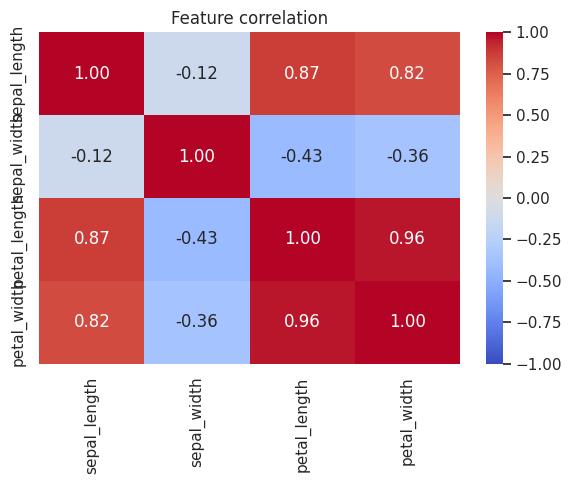

In [29]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[FEATURES].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature correlation")
plt.tight_layout()
plt.savefig("images/04_correlation.png", dpi=120)
plt.show()

## Step 6 — Split into training and testing sets
**Why:** A model must be judged on flowers it has **never seen**. We keep 20% aside as a test set (like a final exam) and train on the other 80%.

- `stratify=y` keeps the same species proportions in both sets.
- `random_state` makes the split reproducible.

**Feature engineering / selection:** with only four clean, meaningful measurements, we keep all four. Creating extra features would add complexity without a clear benefit.

In [30]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Training set:", X_train.shape, "| Test set:", X_test.shape)
print("\nTest-set class counts:\n", y_test.value_counts())

Training set: (119, 4) | Test set: (30, 4)

Test-set class counts:
 species
versicolor    10
virginica     10
setosa        10
Name: count, dtype: int64


## Step 7 — Model selection (and why these models)
We compare five classic classifiers:

| Model | Idea in one line |
|---|---|
| Logistic Regression | Draws straight-line boundaries between classes; simple and interpretable |
| K-Nearest Neighbours (KNN) | A new flower gets the species of its *k* closest neighbours |
| Decision Tree | Asks yes/no questions ("petal length < 2.5 cm?") |
| Support Vector Machine (SVM) | Finds the boundary with the widest safety margin |
| Random Forest | Many decision trees vote; more stable than one tree |

**Pipeline + StandardScaler:** KNN, SVM and Logistic Regression are sensitive to feature scale, so we standardise features (mean 0, std 1). Putting the scaler **inside** a `Pipeline` means it is fitted only on the training data during each step — this prevents **data leakage** (information from the test set sneaking into training).

**Cross-validation (5-fold):** the training set is split into 5 parts; each model is trained 5 times, each time tested on a different part. The average score is a more reliable comparison than one lucky/unlucky split. The test set is **not** touched here.

**Expected output:** a table of mean CV accuracy (± standard deviation) for each model. Scores on Iris are typically high for all models; small differences between them are often within noise.

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM (RBF kernel)": SVC(kernel="rbf", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []
for name, model in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    cv_results.append({"Model": name, "CV mean accuracy": scores.mean(), "CV std": scores.std()})

cv_df = pd.DataFrame(cv_results).sort_values("CV mean accuracy", ascending=False).reset_index(drop=True)
cv_df.round(4)

,Model,CV mean accuracy,CV std
0,Logistic Regression,0.9656,0.0506
1,SVM (RBF kernel),0.9652,0.0696
2,KNN (k=5),0.9572,0.0476
3,Decision Tree,0.9319,0.0591
4,Random Forest,0.9319,0.0591


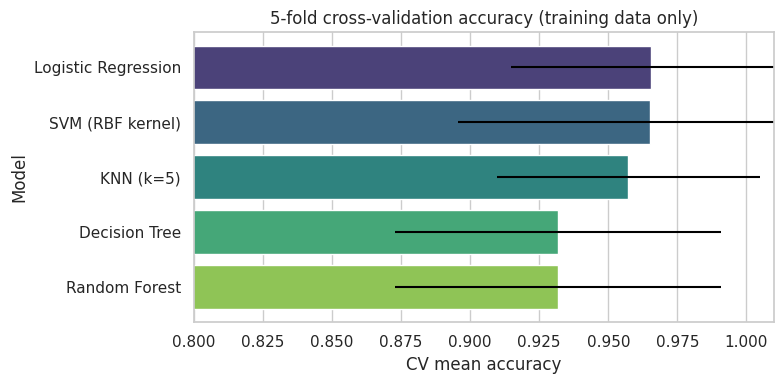

In [32]:
plt.figure(figsize=(8, 4))
sns.barplot(data=cv_df, x="CV mean accuracy", y="Model", hue="Model", palette="viridis", legend=False)
plt.errorbar(cv_df["CV mean accuracy"], range(len(cv_df)), xerr=cv_df["CV std"], fmt="none", c="black")
plt.xlim(0.8, 1.01)
plt.title("5-fold cross-validation accuracy (training data only)")
plt.tight_layout()
plt.savefig("images/05_model_comparison.png", dpi=120)
plt.show()

## Step 8 — Train the best model
We pick the model with the highest mean cross-validation accuracy and train it on the **whole** training set.

*Note:* if two models tie, the table order decides. Any of the top models is a reasonable choice on Iris; mention this honestly if asked.

In [33]:
best_name = cv_df.loc[0, "Model"]
best_model = Pipeline([("scaler", StandardScaler()), ("model", models[best_name])])
best_model.fit(X_train, y_train)
print("Selected model:", best_name)

Selected model: Logistic Regression


## Step 9 — Predict on the test set

In [34]:
y_pred = best_model.predict(X_test)
comparison = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})
comparison["Correct?"] = comparison["Actual"] == comparison["Predicted"]
comparison.head(10)

,Actual,Predicted,Correct?
0,versicolor,versicolor,True
1,versicolor,versicolor,True
2,virginica,virginica,True
3,setosa,setosa,True
4,virginica,virginica,True
5,versicolor,versicolor,True
6,versicolor,versicolor,True
7,setosa,setosa,True
8,virginica,virginica,True
9,virginica,virginica,True


## Step 10 — Evaluate the model
**Key metrics (explained with Iris):**
- **Accuracy** — % of test flowers classified correctly.
- **Precision** (for a species) — of the flowers the model *called* virginica, how many really were virginica? (Low precision = many false alarms.)
- **Recall** (for a species) — of all the *real* virginica flowers, how many did the model find? (Low recall = many missed.)
- **F1-score** — a single balance of precision and recall (their harmonic mean).
- **Macro average** — average over the three species, treating each species equally.

**Expected output:** your real numbers. With only ~30 test flowers, **one mistake changes accuracy by about 3 percentage points**, so don't over-interpret small differences.

In [35]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print(f"Model: {best_name}")
print(f"Test accuracy : {acc:.4f}")
print(f"Macro precision: {prec:.4f}")
print(f"Macro recall   : {rec:.4f}")
print(f"Macro F1-score : {f1:.4f}")
print(f"Misclassified  : {(y_test.values != y_pred).sum()} of {len(y_test)} test flowers\n")
print(classification_report(y_test, y_pred, digits=4))

Model: Logistic Regression
Test accuracy : 0.9333
Macro precision: 0.9333
Macro recall   : 0.9333
Macro F1-score : 0.9333
Misclassified  : 2 of 30 test flowers

              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.9000    0.9000    0.9000        10
   virginica     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30



## Step 11 — Confusion matrix
**How to read it:** rows = true species, columns = predicted species. Numbers on the diagonal are correct predictions; anything off the diagonal is a mistake (e.g. a versicolor predicted as virginica).

**What you'll usually see:** setosa is always correct; any errors are between versicolor and virginica — matching what we saw in the pair plot.

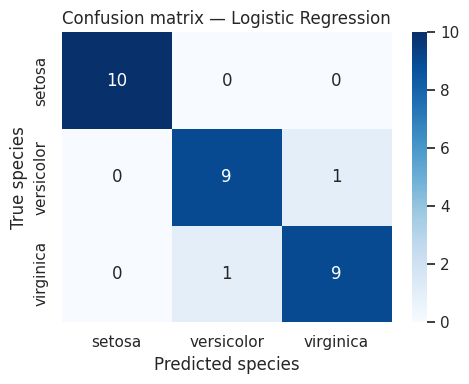

In [36]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted species")
plt.ylabel("True species")
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.savefig("images/06_confusion_matrix.png", dpi=120)
plt.show()

## Step 12 — Which measurements matter most?
We train a Random Forest (on training data only) just to read its **feature importances** — how much each feature helped the trees split the classes. This is for interpretation; it does not change the selected model.

**Expected:** petal measurements usually dominate; sepal width usually matters least.

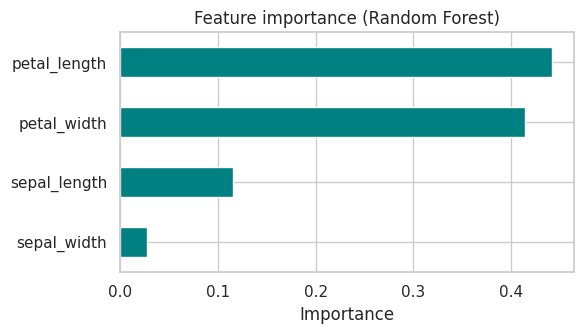

petal_length    0.442
petal_width     0.415
sepal_length    0.116
sepal_width     0.027
dtype: float64


In [37]:
rf_for_importance = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_for_importance.fit(X_train, y_train)
importances = pd.Series(rf_for_importance.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(6, 3.5))
importances.plot(kind="barh", color="teal")
plt.title("Feature importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("images/07_feature_importance.png", dpi=120)
plt.show()
print(importances.sort_values(ascending=False).round(3))

## Step 13 — Decision regions (visual intuition)
To draw boundaries in 2-D we train a small copy of the chosen model on **only the two petal features**. The coloured areas show which species the model would predict for any petal size. This is a teaching visual; the real model uses all four features.

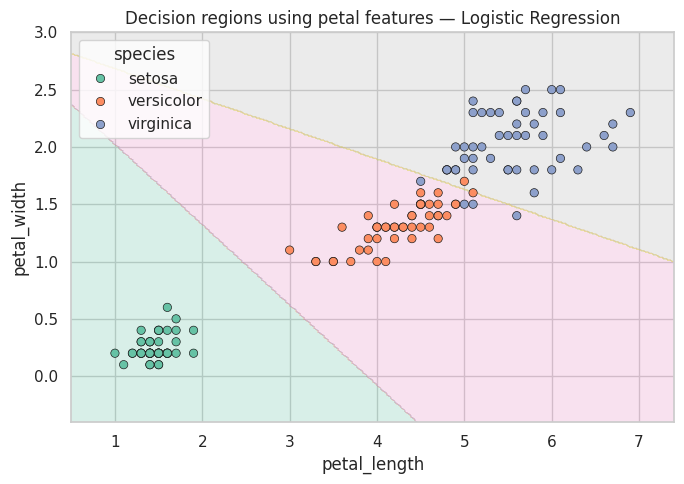

In [38]:
petal_feats = ["petal_length", "petal_width"]
viz_model = Pipeline([("scaler", StandardScaler()), ("model", models[best_name].__class__(**models[best_name].get_params()))])
viz_model.fit(X_train[petal_feats], y_train)

x_min, x_max = X[petal_feats[0]].min() - 0.5, X[petal_feats[0]].max() + 0.5
y_min, y_max = X[petal_feats[1]].min() - 0.5, X[petal_feats[1]].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=petal_feats)
zz = pd.Series(viz_model.predict(grid)).map({s: i for i, s in enumerate(labels)}).values.reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, zz, alpha=0.25, cmap="Set2")
sns.scatterplot(data=df, x=petal_feats[0], y=petal_feats[1], hue=TARGET, palette="Set2", edgecolor="k")
plt.title(f"Decision regions using petal features — {best_name}")
plt.tight_layout()
plt.savefig("images/08_decision_regions.png", dpi=120)
plt.show()

## Step 14 — Save the model and predict a new flower
`joblib.dump` saves the whole pipeline (scaler + model) so you can reuse it later without retraining. Then we load it back and classify a new, made-up flower.

In [39]:
MODEL_PATH = "models/iris_best_model.joblib"
joblib.dump(best_model, MODEL_PATH)
print("Model saved to", MODEL_PATH)

loaded_model = joblib.load(MODEL_PATH)
new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=FEATURES)   # measurements in cm
print("Prediction for", new_flower.values.tolist()[0], "->", loaded_model.predict(new_flower)[0])

Model saved to models/iris_best_model.joblib
Prediction for [5.1, 3.5, 1.4, 0.2] -> setosa


In [40]:
def predict_species(sepal_length, sepal_width, petal_length, petal_width, model=loaded_model):
    """Return the predicted species for one flower (all measurements in cm)."""
    sample = pd.DataFrame([[sepal_length, sepal_width, petal_length, petal_width]], columns=FEATURES)
    return model.predict(sample)[0]

print(predict_species(6.7, 3.0, 5.2, 2.3))
print(predict_species(5.9, 2.8, 4.3, 1.3))

virginica
versicolor


## Step 15 — Results summary (fill in from YOUR run)
Copy these numbers into the README "Results" section.

In [41]:
summary = pd.DataFrame({
    "Metric": ["Best model", "Test accuracy", "Macro precision", "Macro recall", "Macro F1", "Test samples"],
    "Value": [best_name, round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4), len(y_test)],
})
summary.to_csv("images/results_summary.csv", index=False)
summary

,Metric,Value
0,Best model,Logistic Regression
1,Test accuracy,0.9333
2,Macro precision,0.9333
3,Macro recall,0.9333
4,Macro F1,0.9333
5,Test samples,30


## Step 16 — Conclusions, limitations and improvements
**Conclusions (verify against your own output):**
- The four measurements are enough to classify Iris species very accurately.
- Petal length and width are the most informative features; setosa is perfectly separable, and any errors occur between versicolor and virginica.

**Limitations:**
- Only ~150 flowers and a test set of ~30 → results vary noticeably with the random split. Cross-validation gives the more reliable comparison.
- The dataset is clean and "textbook"; real-world data (photos, noisy measurements) is much harder.

**Possible improvements:** repeated cross-validation, hyper-parameter tuning with `GridSearchCV`, testing on flowers measured independently, or a small web app (Streamlit) that uses the saved model.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')